# Test lecture glass

Notebook teste pipeline sur nouveau montage glass

Objectif :
- prendre un scan with water et un scan without water
- afficher I(t)
- reconstruire I0(t)
- calculer A(t)
- puis extraire F_p95 et calculer une HA indicative avec la calibration actuelle.

Ici, on cherche d'abord à voir si pipeline tient visuellement sur ces nouvelles données.


In [2]:
# [Guide] Imports + accès au code source du projet.
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
try:
    from IPython import get_ipython
except Exception:
    get_ipython = None

ip = get_ipython() if get_ipython else None
if ip is not None:
    # Notebook session: inline rendering
    matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
else:
    # Script/headless fallback
    os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
    os.environ.setdefault('XDG_CACHE_HOME', '/tmp')
    matplotlib.use('Agg')

import matplotlib.pyplot as plt


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'laser_matching_calibration.py').exists():
            return candidate
    raise FileNotFoundError('Impossible de trouver la racine du repo depuis le notebook.')


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from laser_matching_calibration import read_signal, compute_I0, compute_A_full, extract_features
from predict_ha import load_feature_name, load_coefficients, DEFAULT_RUN_SUMMARY, DEFAULT_CALIB_METRICS

DATA_DIR = REPO_ROOT / 'data' / 'test_glass_with_resitor_AO'
print('REPO_ROOT =', REPO_ROOT)
print('DATA_DIR =', DATA_DIR)
print('DATA_DIR exists =', DATA_DIR.exists())
print('matplotlib backend =', matplotlib.get_backend())


REPO_ROOT = /Users/valonmehmeti/hesso/PI
DATA_DIR = /Users/valonmehmeti/hesso/PI/data/test_glass_with_resitor_AO
DATA_DIR exists = True
matplotlib backend = module://matplotlib_inline.backend_inline


In [3]:
# [Guide] Liste des fichiers disponibles.
files = sorted(DATA_DIR.glob('*.txt'))
df_files = pd.DataFrame({'file': [p.name for p in files]})
display(df_files)


,file
0,glass_with_water_0.txt
1,glass_with_water_1.txt
2,glass_with_water_2.txt
3,glass_with_water_3.txt
4,glass_with_water_4.txt
5,glass_with_water_5.txt
6,glass_with_water_6.txt
7,glass_with_water_7.txt
8,glass_with_water_8.txt
9,glass_with_water_9.txt


In [4]:
# [Guide] Choix d'un exemple without water et d'un exemple with water.
WITHOUT_PATH = DATA_DIR / 'glass_witout_water_0.txt'
WITH_PATH = DATA_DIR / 'glass_with_water_0.txt'

print('WITHOUT_PATH =', WITHOUT_PATH.name, 'exists =', WITHOUT_PATH.exists())
print('WITH_PATH    =', WITH_PATH.name, 'exists =', WITH_PATH.exists())


WITHOUT_PATH = glass_witout_water_0.txt exists = True
WITH_PATH    = glass_with_water_0.txt exists = True


In [5]:
# [Guide] Lecture des deux signaux bruts I(t).
I_without = read_signal(WITHOUT_PATH)
I_with = read_signal(WITH_PATH)

print('without_water: n =', len(I_without), 'min =', float(I_without.min()), 'max =', float(I_without.max()))
print('with_water   : n =', len(I_with), 'min =', float(I_with.min()), 'max =', float(I_with.max()))


without_water: n = 8192 min = -0.421938 max = 0.594475
with_water   : n = 8192 min = -0.398634 max = 0.584616


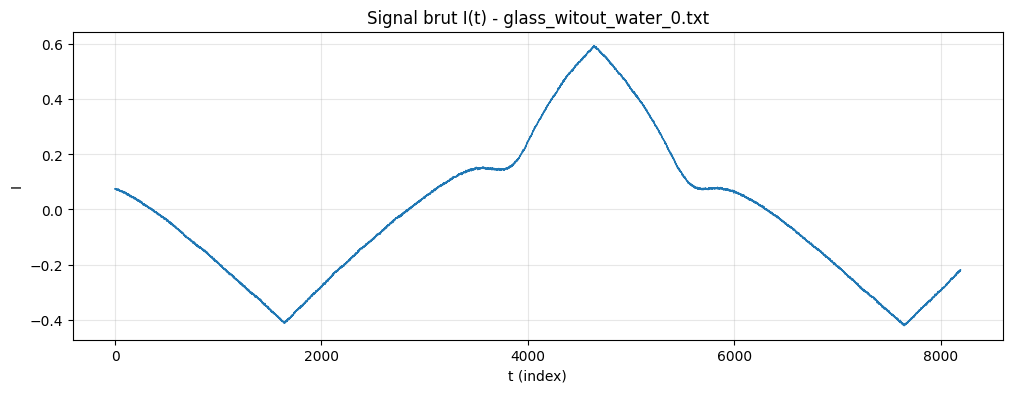

In [6]:
# [Guide] Signal brut I(t) pour le cas without water.
plt.figure(figsize=(12, 4))
plt.plot(I_without, lw=1)
plt.title(f'Signal brut I(t) - {WITHOUT_PATH.name}')
plt.xlabel('t (index)')
plt.ylabel('I')
plt.grid(True, alpha=0.3)
plt.show()


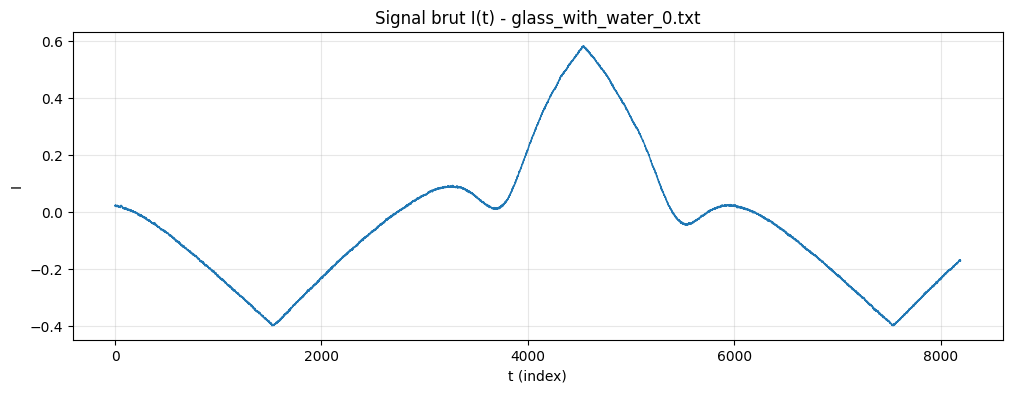

In [7]:
# [Guide] Signal brut I(t) pour le cas with water.
plt.figure(figsize=(12, 4))
plt.plot(I_with, lw=1)
plt.title(f'Signal brut I(t) - {WITH_PATH.name}')
plt.xlabel('t (index)')
plt.ylabel('I')
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
# [Guide] Construction de la baseline I0(t) sur les deux scans.
I0_without = compute_I0(I_without, smooth_window=41, k=0.20)
I0_with = compute_I0(I_with, smooth_window=41, k=0.20)

print('I0_without min/max =', float(I0_without.min()), float(I0_without.max()))
print('I0_with    min/max =', float(I0_with.min()), float(I0_with.max()))


I0_without min/max = -0.373537 0.594475
I0_with    min/max = -0.33485405430983506 0.584616


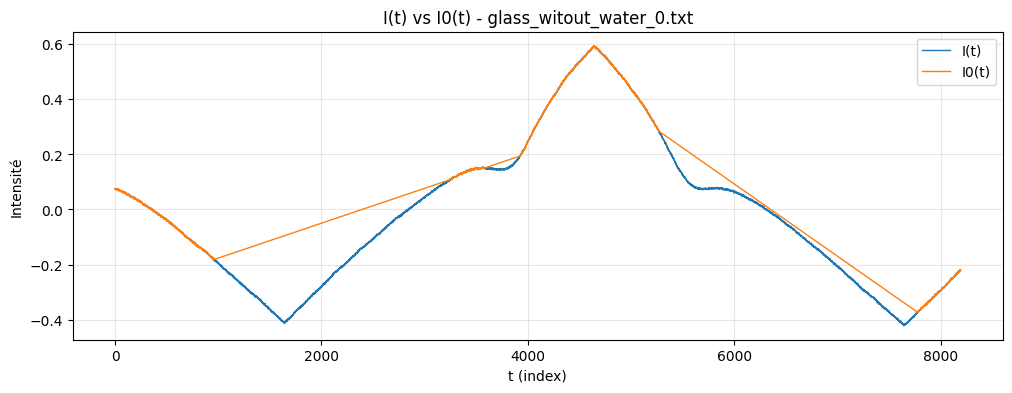

In [9]:
# [Guide] Comparaison I(t) vs I0(t) pour le cas without water.
plt.figure(figsize=(12, 4))
plt.plot(I_without, lw=1, label='I(t)')
plt.plot(I0_without, lw=1, label='I0(t)')
plt.title(f'I(t) vs I0(t) - {WITHOUT_PATH.name}')
plt.xlabel('t (index)')
plt.ylabel('Intensité')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


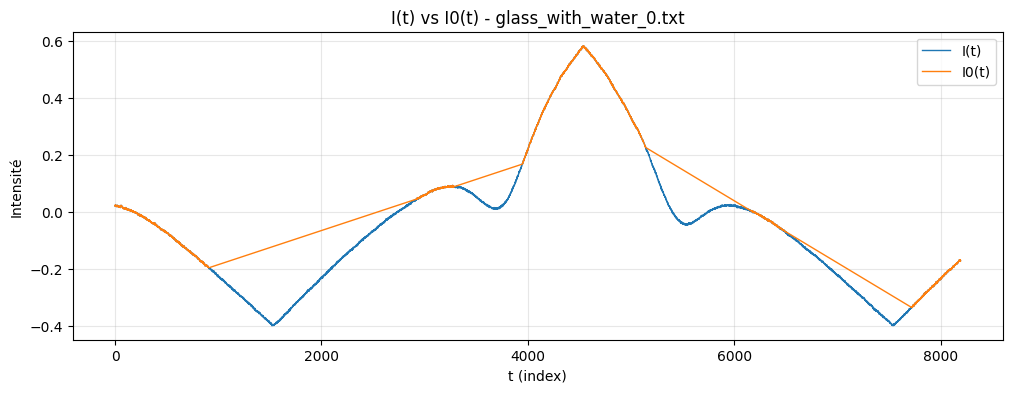

In [10]:
# [Guide] Comparaison I(t) vs I0(t) pour le cas with water.
plt.figure(figsize=(12, 4))
plt.plot(I_with, lw=1, label='I(t)')
plt.plot(I0_with, lw=1, label='I0(t)')
plt.title(f'I(t) vs I0(t) - {WITH_PATH.name}')
plt.xlabel('t (index)')
plt.ylabel('Intensité')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [11]:
# [Guide] Calcul de l'absorbance A(t) sur les deux scans.
A_without = compute_A_full(I_without, I0_without)
A_with = compute_A_full(I_with, I0_with)

print('A_without min/max =', float(A_without.min()), float(A_without.max()))
print('A_with    min/max =', float(A_with.min()), float(A_with.max()))


A_without min/max = -0.0 17.871840993190833
A_with    min/max = -0.0 18.95666209377646


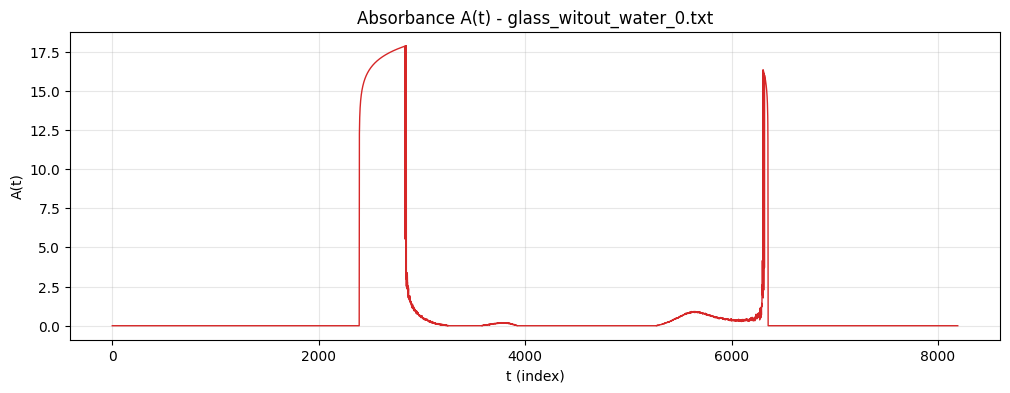

In [12]:
# [Guide] Absorbance A(t) pour le cas without water.
plt.figure(figsize=(12, 4))
plt.plot(A_without, lw=1, color='tab:red')
plt.title(f'Absorbance A(t) - {WITHOUT_PATH.name}')
plt.xlabel('t (index)')
plt.ylabel('A(t)')
plt.grid(True, alpha=0.3)
plt.show()


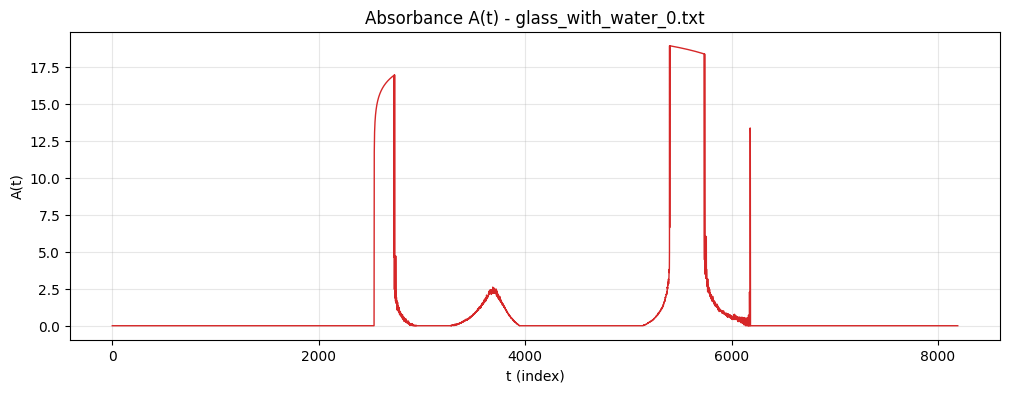

In [13]:
# [Guide] Absorbance A(t) pour le cas with water.
plt.figure(figsize=(12, 4))
plt.plot(A_with, lw=1, color='tab:red')
plt.title(f'Absorbance A(t) - {WITH_PATH.name}')
plt.xlabel('t (index)')
plt.ylabel('A(t)')
plt.grid(True, alpha=0.3)
plt.show()


In [14]:
# [Guide] Extraction des features et calcul de HA indicative.
feature_name = load_feature_name(DEFAULT_RUN_SUMMARY, None)
intercept, slope = load_coefficients(DEFAULT_CALIB_METRICS, feature_name, None, None)

features_without = extract_features(A_without, edge=20)
features_with = extract_features(A_with, edge=20)

HA_without = intercept + slope * float(features_without[feature_name])
HA_with = intercept + slope * float(features_with[feature_name])

summary = pd.DataFrame([
    {
        'case': 'without_water',
        'file': WITHOUT_PATH.name,
        'neg_frac_I': float((I_without <= 0).mean()),
        'F_p95': float(features_without['F_p95']),
        'F_area_total': float(features_without['F_area_total']),
        'HA_pred_indicative': float(HA_without),
    },
    {
        'case': 'with_water',
        'file': WITH_PATH.name,
        'neg_frac_I': float((I_with <= 0).mean()),
        'F_p95': float(features_with['F_p95']),
        'F_area_total': float(features_with['F_area_total']),
        'HA_pred_indicative': float(HA_with),
    },
])

display(summary)
print(f'Formule appliquée : HA = {intercept:.8f} + {slope:.8f} * {feature_name}')


,case,file,neg_frac_I,F_p95,F_area_total,HA_pred_indicative
0,without_water,glass_witout_water_0.txt,0.532715,15.777681,9083.232671,26339.572755
1,with_water,glass_with_water_0.txt,0.595459,16.534290,10999.719152,27602.765784


Formule appliquée : HA = -1.95838174 + 1669.54392698 * F_p95


## Lecture du résultat

Ce notebook ne dit pas encore si la valeur finale de `HA` est physiquement juste sur le montage `glass`.

Il permet d'abord de voir :
- si le signal brut `I(t)` ressemble à quelque chose d'exploitable,
- si la baseline `I0(t)` se reconstruit proprement,
- si l'absorbance `A(t)` a une forme cohérente,
- et comment se comportent `F_p95` et la `HA` indicative.
